In [14]:
import pandas as pd
file_path = r'/Users/misbahuddinalif/Downloads/customer_shopping_data (1).csv'
df = pd.read_csv(file_path)
df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park


In [15]:
df.dtypes

invoice_no            str
customer_id           str
gender                str
age                 int64
category              str
quantity            int64
price             float64
payment_method        str
invoice_date          str
shopping_mall         str
dtype: object

In [16]:
df.isna().mean()*100

invoice_no        0.0
customer_id       0.0
gender            0.0
age               0.0
category          0.0
quantity          0.0
price             0.0
payment_method    0.0
invoice_date      0.0
shopping_mall     0.0
dtype: float64

In [17]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [18]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [19]:
#A model that predicts price

df.corr(numeric_only=True)

,age,quantity,price
age,1.000000,0.000667,0.001694
quantity,0.000667,1.000000,0.344880
price,0.001694,0.344880,1.000000


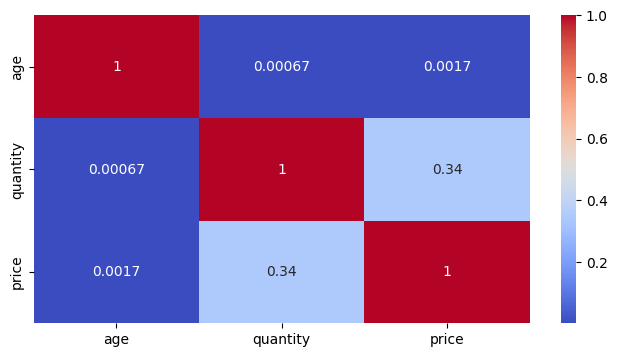

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

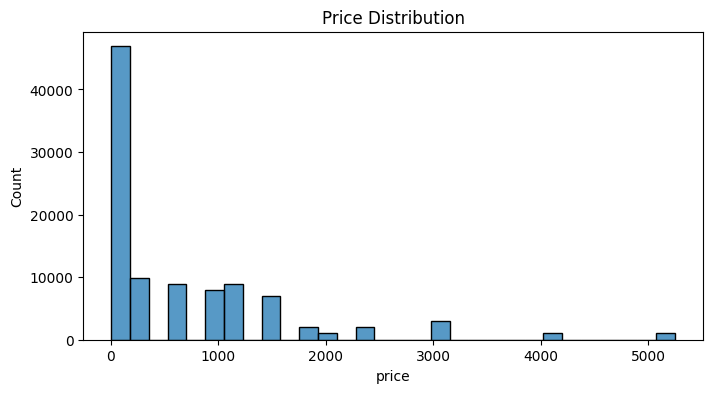

count    99457.000000
mean       689.256321
std        941.184567
min          5.230000
25%         45.450000
50%        203.300000
75%       1200.320000
max       5250.000000
Name: price, dtype: float64


In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='price', bins=30)
plt.title('Price Distribution')
plt.show()

print(df['price'].describe())

               age  quantity     price
age       1.000000  0.000667  0.001694
quantity  0.000667  1.000000  0.344880
price     0.001694  0.344880  1.000000


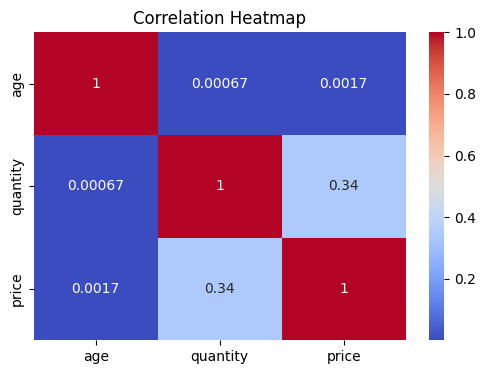

In [22]:
print(df.corr(numeric_only=True))

plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

category
Technology         3156.935548
Shoes              1807.388568
Clothing            901.084021
Cosmetics           122.448626
Toys                107.733185
Books                45.568621
Souvenir             34.894345
Food & Beverage      15.671948
Name: price, dtype: float64


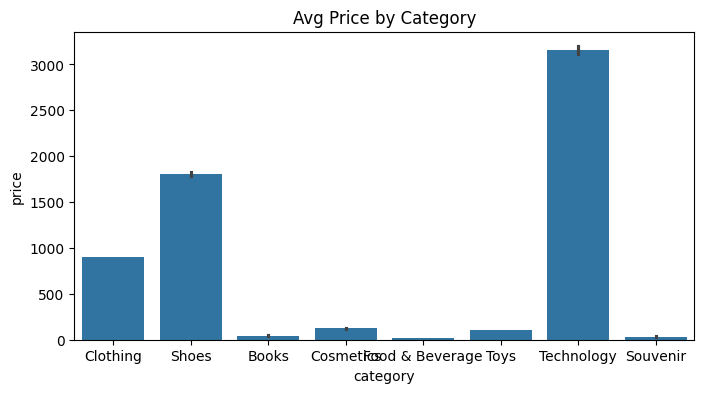

In [26]:
print(df.groupby('category')['price'].mean().sort_values(ascending=False))

plt.figure(figsize=(8, 4))
sns.barplot(x='category', y='price', data=df)
plt.title('Avg Price by Category')
plt.show()

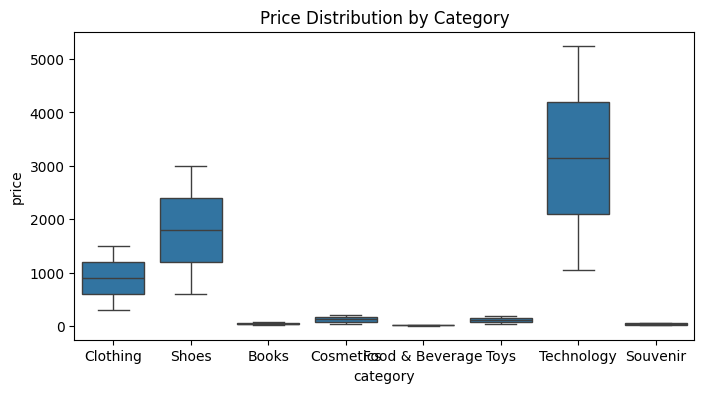

In [28]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='category', y='price', data=df)
plt.title('Price Distribution by Category')
plt.show()

In [ ]:
from sklearn linear_model import LinearRegression
model = LinearRegression()
x = df ['price']
y = 